"""
SCAPS-1D Batch IV Parser & Plotter — IV_thickness.iv
======================================================

WHAT THIS DATASET IS:
---------------------
This is a SCAPS-1D batch simulation sweeping TWO parameters simultaneously:
  • PAL1 thickness — MAPbI3-xClx absorber layer (0.3 µm → 1.3 µm)
  • PAL2 thickness — MAPbI3+Ti3C2 MXene absorber layer (0.3 µm → 1.3 µm)

Grid size  : 11 × 11 = 121 simulation steps
Conditions : AM 1.5G, 100 mW/cm², T = 300 K

WHAT IT INDICATES:
------------------
Each simulation point gives you the solar cell parameters (Jsc, Voc, FF, PCE)
for a specific combination of PAL1 and PAL2 thicknesses. By mapping all 121
points as a contour plot, you can visually identify:

  ✔ Which thickness combination gives the highest PCE  → optimum design point
  ✔ How Jsc changes with PAL1 thickness                → light absorption effect
  ✔ How Voc changes                                    → recombination / field effect
  ✔ How FF changes                                     → charge transport / resistance effect

Comparing this with IV_defect.iv (same thickness sweep but different defect
density settings) lets you isolate the effect of defects vs thickness on PCE.
This directly replicates Fig. 2 of Bhattarai et al., J. Phys. Chem. Solids 2025.

HOW TO RUN:
-----------
  pip install numpy matplotlib scipy pandas
  python plot_IV_thickness.py
"""

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import griddata

In [2]:
FILENAME = "IV_thickness.iv"   # keep this script in the same folder as the .iv file

records  = []   # list of dicts: {pal1, pal2, jsc, voc, ff, pce}
jv_store = {}   # key: (pal1, pal2) → (voltage_array, current_array)

print(f"Reading {FILENAME} …")

with open(FILENAME, "r", encoding="utf-8", errors="replace") as f:
    lines = f.readlines()

total_lines = len(lines)
print(f"Total lines in file : {total_lines}")

i = 0
while i < total_lines:
    line = lines[i]

    # ── Detect a batch-parameter block ────────────────────────────────────────
    if "**Batch parameters**" in line:
        pal1, pal2 = None, None

        # The next 2–4 lines hold PAL1 and PAL2 thickness values
        for offset in range(1, 6):
            if i + offset >= total_lines:
                break
            pl = lines[i + offset]
            if "PAL1" in pl and "thickness" in pl:
                m = re.search(r":\s*([\d.eE+\-]+)", pl)
                if m:
                    pal1 = round(float(m.group(1)), 4)
            if "PAL2" in pl and "thickness" in pl:
                m = re.search(r":\s*([\d.eE+\-]+)", pl)
                if m:
                    pal2 = round(float(m.group(1)), 4)

        # ── Scan forward for J-V data rows AND solar cell parameters ──────────
        voltages, currents = [], []
        voc = jsc = ff = pce = None
        in_data = False

        for j in range(i + 1, min(i + 250, total_lines)):
            sl = lines[j]

            # Detect the data table header
            if "v(V)" in sl and "jtot" in sl:
                in_data = True
                continue

            # Parse data rows (illuminated: jtot < 0 at V = 0)
            if in_data:
                parts = sl.strip().split()
                if len(parts) >= 2:
                    try:
                        v     = float(parts[0])
                        j_tot = float(parts[1])
                        voltages.append(v)
                        currents.append(j_tot)
                        continue
                    except ValueError:
                        in_data = False

            # Parse the summary block
            if re.match(r"\s*Voc\s*=", sl):
                m = re.search(r"=\s*([\d.eE+\-]+)", sl)
                if m:
                    voc = float(m.group(1))
            elif re.match(r"\s*Jsc\s*=", sl):
                m = re.search(r"=\s*([\d.eE+\-]+)", sl)
                if m:
                    jsc = float(m.group(1))
            elif re.match(r"\s*FF\s*=", sl):
                m = re.search(r"=\s*([\d.eE+\-]+)", sl)
                if m:
                    ff = float(m.group(1))
            elif re.match(r"\s*eta\s*=", sl):
                m = re.search(r"=\s*([\d.eE+\-]+)", sl)
                if m:
                    pce = float(m.group(1))

            # Stop when the next SCAPS header starts
            if "SCAPS 3.3" in sl and j > i + 5:
                break

        # Store if fully parsed
        if all(v is not None for v in [pal1, pal2, voc, jsc, ff, pce]):
            records.append({"pal1": pal1, "pal2": pal2,
                            "jsc": jsc, "voc": voc, "ff": ff, "pce": pce})
            key = (pal1, pal2)
            if voltages and key not in jv_store:
                jv_store[key] = (np.array(voltages), np.array(currents))

    i += 1

print(f"✓ Parsed {len(records)} batch records\n")
if not records:
    raise SystemExit("❌ No records found. Check the file path or format.")

Reading IV_thickness.iv …
Total lines in file : 10511
✓ Parsed 121 batch records



In [3]:
pal1_arr = np.array([r["pal1"] for r in records])
pal2_arr = np.array([r["pal2"] for r in records])
jsc_arr  = np.array([r["jsc"]  for r in records])
voc_arr  = np.array([r["voc"]  for r in records])
ff_arr   = np.array([r["ff"]   for r in records])
pce_arr  = np.array([r["pce"]  for r in records])

pal1_unique = np.unique(pal1_arr)
pal2_unique = np.unique(pal2_arr)

print("PAL1 unique values (µm) :", pal1_unique)
print("PAL2 unique values (µm) :", pal2_unique)
print(f"\nBest PCE : {pce_arr.max():.4f}%  →  "
      f"PAL1={pal1_arr[np.argmax(pce_arr)]:.2f}µm, "
      f"PAL2={pal2_arr[np.argmax(pce_arr)]:.2f}µm")
print(f"Jsc range : {jsc_arr.min():.2f} – {jsc_arr.max():.2f}  mA/cm²")
print(f"Voc range : {voc_arr.min():.3f} – {voc_arr.max():.3f}  V")
print(f"FF  range : {ff_arr.min():.2f}  – {ff_arr.max():.2f}   %")
print(f"PCE range : {pce_arr.min():.2f}  – {pce_arr.max():.2f}  %")

PAL1 unique values (µm) : [0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3]
PAL2 unique values (µm) : [0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3]

Best PCE : 24.3940%  →  PAL1=0.50µm, PAL2=0.30µm
Jsc range : 30.54 – 34.51  mA/cm²
Voc range : 1.041 – 3.655  V
FF  range : 21.02  – 51.54   %
PCE range : 16.96  – 24.39  %


In [4]:
xi = np.linspace(pal1_arr.min(), pal1_arr.max(), 300)
yi = np.linspace(pal2_arr.min(), pal2_arr.max(), 300)
XI, YI = np.meshgrid(xi, yi)
pts = np.column_stack([pal1_arr, pal2_arr])

ZI = {
    "Jsc (mA/cm²)" : griddata(pts, jsc_arr, (XI, YI), method="cubic"),
    "Voc (V)"       : griddata(pts, voc_arr, (XI, YI), method="cubic"),
    "FF (%)"        : griddata(pts, ff_arr,  (XI, YI), method="cubic"),
    "PCE (%)"       : griddata(pts, pce_arr, (XI, YI), method="cubic"),
}

CMAPS = {
    "Jsc (mA/cm²)" : "YlOrRd",
    "Voc (V)"       : "YlGnBu",
    "FF (%)"        : "RdYlGn",
    "PCE (%)"       : "RdYlGn",
}
TAGS = ["(a)", "(b)", "(c)", "(d)"]


✓ Saved → PAL_thickness_contour.png


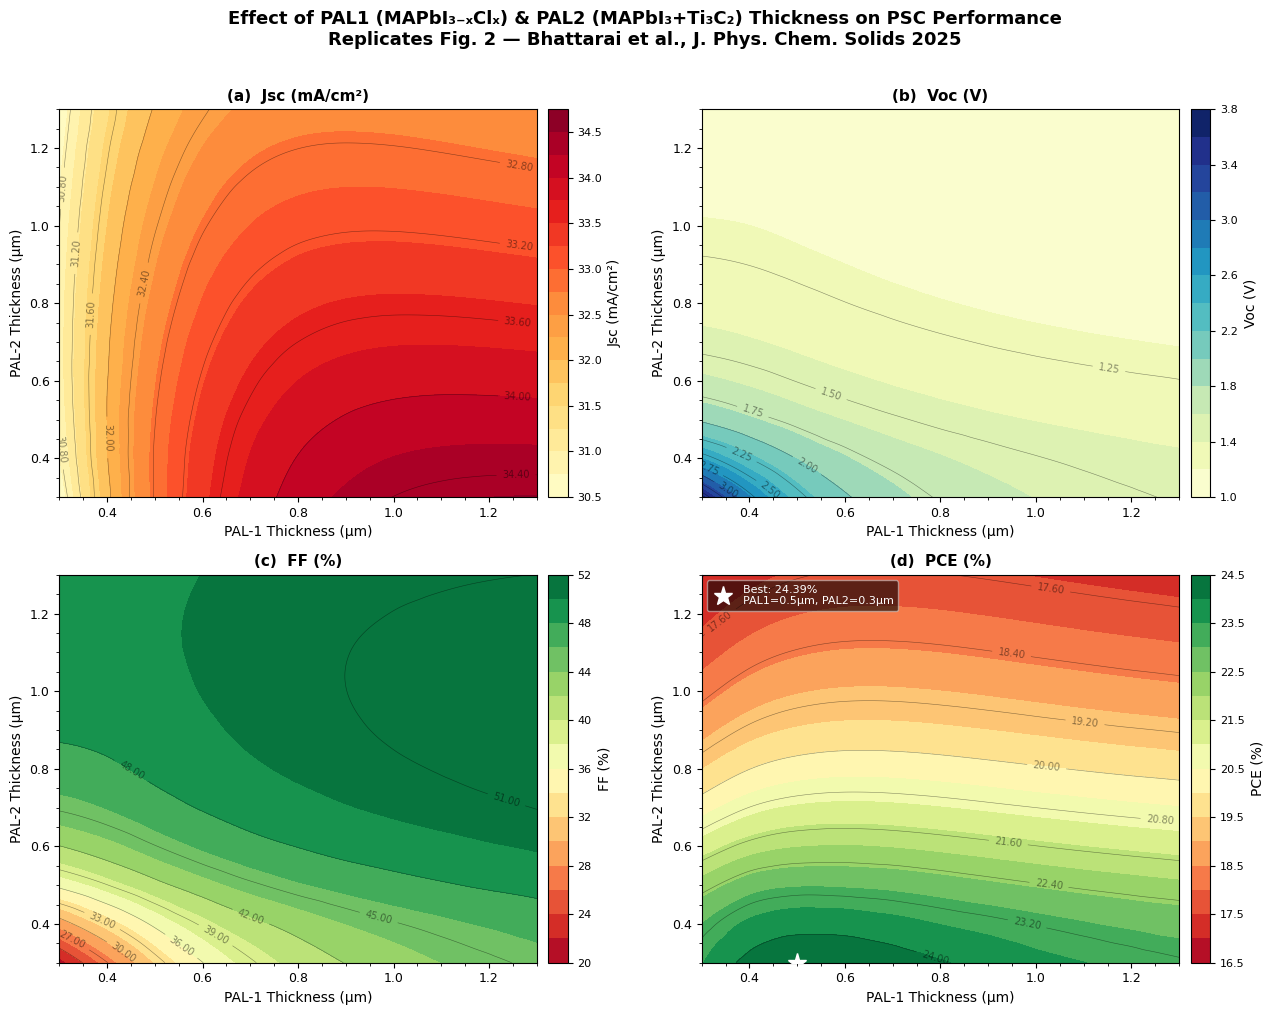

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(
    "Effect of PAL1 (MAPbI₃₋ₓClₓ) & PAL2 (MAPbI₃+Ti₃C₂) Thickness on PSC Performance\n"
    "Replicates Fig. 2 — Bhattarai et al., J. Phys. Chem. Solids 2025",
    fontsize=13, fontweight="bold", y=1.01
)

best_idx = np.argmax(pce_arr)
best_p1  = pal1_arr[best_idx]
best_p2  = pal2_arr[best_idx]

for ax, (label, Z), tag in zip(axes.flat, ZI.items(), TAGS):
    cf = ax.contourf(XI, YI, Z, levels=15, cmap=CMAPS[label])
    cs = ax.contour (XI, YI, Z, levels=10, colors="k", linewidths=0.4, alpha=0.45)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f")

    cbar = fig.colorbar(cf, ax=ax, pad=0.02)
    cbar.set_label(label, fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    # Mark optimum on PCE panel
    if "PCE" in label:
        ax.plot(best_p1, best_p2, "w*", markersize=14, zorder=5,
                label=f"Best: {pce_arr.max():.2f}%\nPAL1={best_p1}µm, PAL2={best_p2}µm")
        ax.legend(fontsize=8, loc="upper left",
                  facecolor="black", labelcolor="white", framealpha=0.6)

    ax.set_xlabel("PAL-1 Thickness (µm)", fontsize=10)
    ax.set_ylabel("PAL-2 Thickness (µm)", fontsize=10)
    ax.set_title(f"{tag}  {label}", fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=9)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig("PAL_thickness_contour.png", dpi=300, bbox_inches="tight")
print("\n✓ Saved → PAL_thickness_contour.png")
plt.show()

✓ Saved → PAL_thickness_lines.png


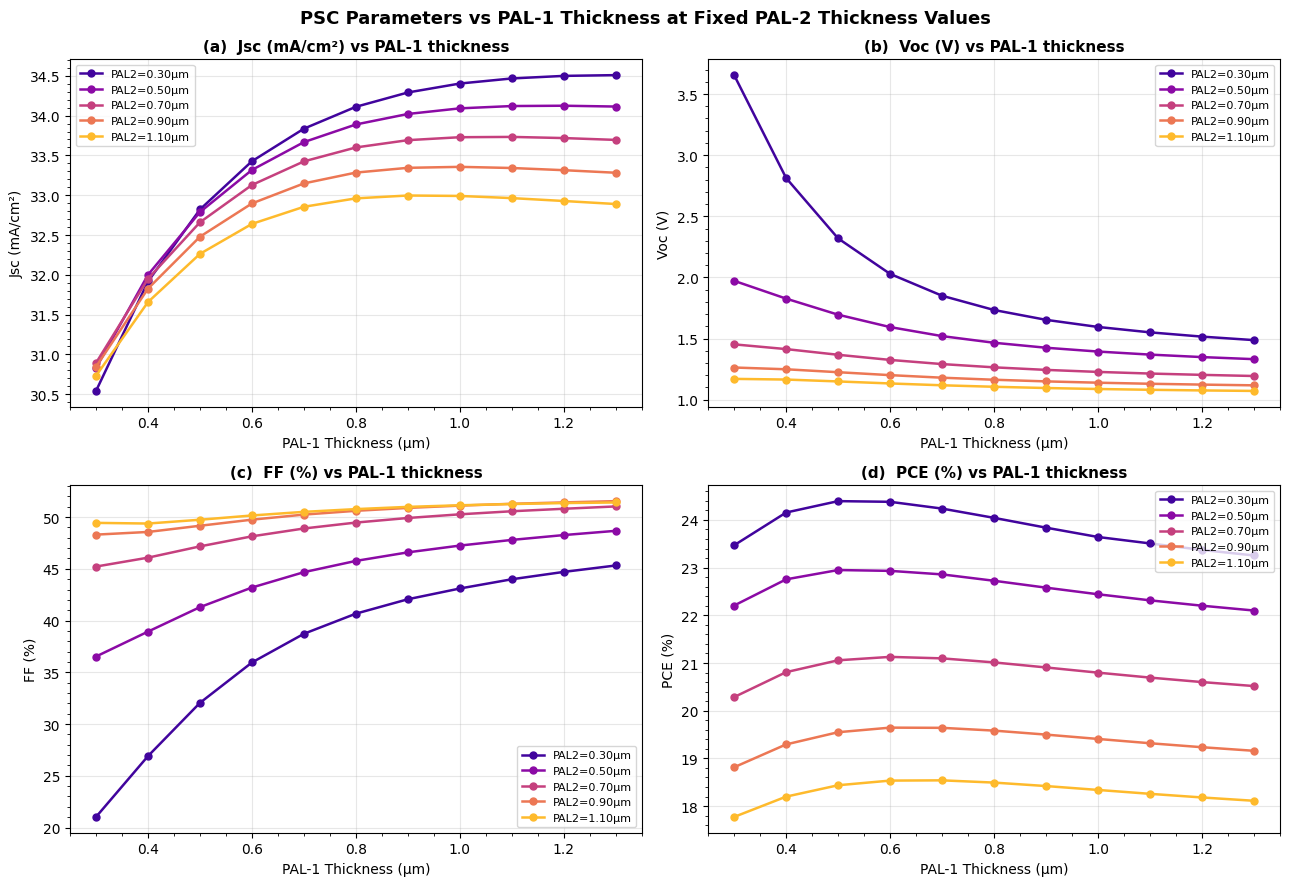

In [6]:
fig2, axes2 = plt.subplots(2, 2, figsize=(13, 9))
fig2.suptitle("PSC Parameters vs PAL-1 Thickness at Fixed PAL-2 Thickness Values",
              fontsize=13, fontweight="bold")

metrics   = [("jsc", "Jsc (mA/cm²)", "tomato"),
             ("voc", "Voc (V)",       "steelblue"),
             ("ff",  "FF (%)",        "seagreen"),
             ("pce", "PCE (%)",       "darkorchid")]

# Pick 5 evenly spaced PAL2 values to plot
pal2_sel = pal2_unique[::max(1, len(pal2_unique)//5)][:5]
colors   = plt.cm.plasma(np.linspace(0.1, 0.85, len(pal2_sel)))

for ax2, (key, ylabel, _), tag in zip(axes2.flat, metrics, TAGS):
    for p2, col in zip(pal2_sel, colors):
        mask  = np.abs(pal2_arr - p2) < 1e-4
        xvals = pal1_arr[mask]
        yvals = np.array([r[key] for r in records])[mask]
        order = np.argsort(xvals)
        ax2.plot(xvals[order], yvals[order], "o-", color=col,
                 linewidth=1.8, markersize=5, label=f"PAL2={p2:.2f}µm")

    ax2.set_xlabel("PAL-1 Thickness (µm)", fontsize=10)
    ax2.set_ylabel(ylabel, fontsize=10)
    ax2.set_title(f"{tag}  {ylabel} vs PAL-1 thickness", fontsize=11, fontweight="bold")
    ax2.legend(fontsize=8, loc="best")
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig("PAL_thickness_lines.png", dpi=300, bbox_inches="tight")
print("✓ Saved → PAL_thickness_lines.png")
plt.show()

✓ Saved → PAL_thickness_JV.png


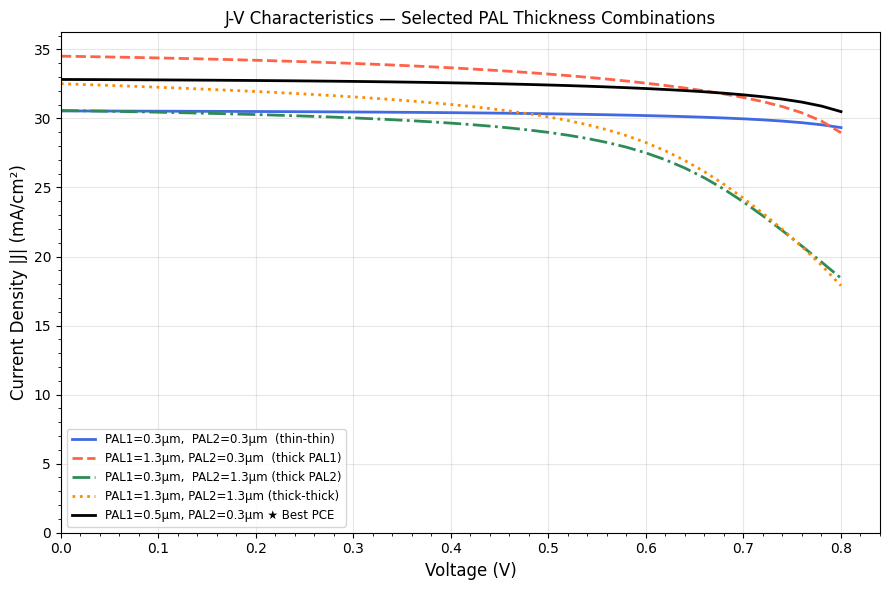

In [7]:
# Select interesting combos: 4 corners + best PCE point
corner_keys = [
    (pal1_unique[0],  pal2_unique[0]),   # thin-thin
    (pal1_unique[-1], pal2_unique[0]),   # thick PAL1 / thin PAL2
    (pal1_unique[0],  pal2_unique[-1]),  # thin PAL1 / thick PAL2
    (pal1_unique[-1], pal2_unique[-1]),  # thick-thick
    (round(best_p1, 4), round(best_p2, 4)),  # best PCE
]
labels_jv = [
    f"PAL1={pal1_unique[0]}µm,  PAL2={pal2_unique[0]}µm  (thin-thin)",
    f"PAL1={pal1_unique[-1]}µm, PAL2={pal2_unique[0]}µm  (thick PAL1)",
    f"PAL1={pal1_unique[0]}µm,  PAL2={pal2_unique[-1]}µm (thick PAL2)",
    f"PAL1={pal1_unique[-1]}µm, PAL2={pal2_unique[-1]}µm (thick-thick)",
    f"PAL1={best_p1}µm, PAL2={best_p2}µm ★ Best PCE",
]
colors_jv = ["royalblue", "tomato", "seagreen", "darkorange", "black"]
styles_jv = ["-", "--", "-.", ":", "-"]

fig3, ax3 = plt.subplots(figsize=(9, 6))
ax3.axhline(0, color="gray", linewidth=0.6, linestyle="--")

for ck, lbl, col, sty in zip(corner_keys, labels_jv, colors_jv, styles_jv):
    # Find the closest key in jv_store
    best_match = None
    best_dist  = 1e9
    for stored_key in jv_store:
        dist = abs(stored_key[0] - ck[0]) + abs(stored_key[1] - ck[1])
        if dist < best_dist:
            best_dist  = dist
            best_match = stored_key

    if best_match is None or best_dist > 0.05:
        continue

    v, j = jv_store[best_match]
    # Only illuminated region (current negative = photogeneration)
    mask = j <= 0.05
    if mask.sum() < 3:
        continue
    ax3.plot(v[mask], np.abs(j[mask]), color=col, linestyle=sty,
             linewidth=2, label=lbl)

ax3.set_xlabel("Voltage (V)", fontsize=12)
ax3.set_ylabel("Current Density |J| (mA/cm²)", fontsize=12)
ax3.set_title("J-V Characteristics — Selected PAL Thickness Combinations", fontsize=12)
ax3.set_xlim(left=0)
ax3.set_ylim(bottom=0)
ax3.legend(fontsize=8.5, loc="lower left")
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig("PAL_thickness_JV.png", dpi=300, bbox_inches="tight")
print("✓ Saved → PAL_thickness_JV.png")
plt.show()

In [8]:
print("\n" + "═"*65)
print(f"{'PAL1(µm)':>10} {'PAL2(µm)':>10} {'Jsc':>10} {'Voc':>8} {'FF':>8} {'PCE':>8}")
print("─"*65)
for r in sorted(records, key=lambda x: -x["pce"])[:10]:
    print(f"{r['pal1']:>10.2f} {r['pal2']:>10.2f} "
          f"{r['jsc']:>10.4f} {r['voc']:>8.4f} {r['ff']:>8.4f} {r['pce']:>8.4f}")
print("═"*65)
print("(Top 10 configurations by PCE)\n")
print("Done. All plots saved.")


═════════════════════════════════════════════════════════════════
  PAL1(µm)   PAL2(µm)        Jsc      Voc       FF      PCE
─────────────────────────────────────────────────────────────────
      0.50       0.30    32.8217   2.3189  32.0511  24.3940
      0.60       0.30    33.4274   2.0287  35.9515  24.3796
      0.70       0.30    33.8362   1.8498  38.7238  24.2374
      0.40       0.30    31.9172   2.8129  26.9047  24.1550
      0.80       0.30    34.1109   1.7332  40.6682  24.0430
      0.90       0.30    34.2907   1.6528  42.0605  23.8375
      0.50       0.40    32.8202   1.9912  36.4453  23.8178
      0.60       0.40    33.3843   1.8144  39.2965  23.8026
      0.70       0.40    33.7623   1.6946  41.3701  23.6691
      1.00       0.30    34.4030   1.5945  43.0986  23.6419
═════════════════════════════════════════════════════════════════
(Top 10 configurations by PCE)

Done. All plots saved.
